# Where is the Quantum diffusion rate identifiable?

`sigma` is the hopping amplitude in the Quantum Hamiltonian. This notebook asks two questions
about the model, not about any dataset:

1. **Does a diffusion rate mean the same thing on a 21-state and a 51-state grid?**
2. **Given 30 trials, which values of `sigma` can be told apart?**

The measure for the second is the expected log-likelihood ratio between two parameter settings,
in nats, over one participant's 30 trials:

$$D(a,b) \;=\; N \sum_{o} p_a(o)\,\log \frac{p_a(o)}{p_b(o)}$$

where $o$ ranges over the model's outcomes: a positive or negative response at each time step,
plus "no valenced response". A gap of $D$ nats is an $e^{D}$ odds ratio, so ~3 nats is weak
evidence and ~10 nats is decisive. No data is used anywhere in this notebook.

In [1]:
import numpy as np, jax, jax.numpy as npx, pandas as pd
from plotnine import *
import cme.decision_models.confidence_accumulation as ca

g++ not available, if using conda: `conda install gxx`


## Configuration

These are the values `fit_emotion_labeling.py` actually runs, not the `ModelDetails` defaults.

In [2]:
grids = {"21 states": (21, 7, 3), "51 states": (51, 17, 3)}
delta, measurement_prob, n_trials = 0.1, 0.75, 30
mu_ref = 0.76
times = np.round(np.arange(delta, 12.0 + delta / 2, delta), 2)

RT = np.asarray(times)[None, :]
RA = np.zeros_like(RT)

## Forward model

`Mn` is the survival operator, so the outcome distribution is the valenced responses at each
step plus the mass that never responded - that is the conservation identity, and it sums to one.

In [3]:
def make_curves(n_states, response_width, n_bins):
    n_free = n_states - 2 * response_width
    Mc, Mw, Mn = ca._get_measurement_matrix(n_states, response_width, measurement_prob, "Quantum")
    conc = ca._initial_state_concentration(n_bins, "Quantum")
    p_free = ca._expand_bins(conc / conc.sum(), n_free, n_bins)
    phi_0 = npx.sqrt(npx.pad(p_free, (response_width, response_width)))[None, None, :, None]

    def curve(mu, sigma):
        G = ca.quantum_buildH(n_states, npx.full((1, 1), mu), npx.full((1, 1), sigma), delta)
        phi_t = ca.perform_state_transition(G, RT, RA, Mc, Mw, Mn, phi_0, delta,
                                            transition_type="TIMESTEP", likelihood_type="SINGLE")
        return npx.stack([(npx.abs(M @ phi_t) ** 2).sum(axis=(-2, -1))[0] for M in (Mc, Mw, Mn)])

    return jax.jit(jax.vmap(curve))


curves_for = {name: make_curves(*g) for name, g in grids.items()}


def outcome_mass(c):
    valenced = c[:, :2, :].reshape(c.shape[0], -1)
    survive = npx.clip(1.0 - valenced.sum(axis=1), 1e-12, None)
    return npx.concatenate([valenced, survive[:, None]], axis=1)


def evidence(p):
    p = npx.clip(p, 1e-12, None)
    return np.array(n_trials * (p[:, None, :] * (npx.log(p)[:, None, :] - npx.log(p)[None, :, :])).sum(-1))


def median_rt(c):
    cum = np.cumsum(np.asarray(c[:, :2, :].sum(axis=1)), axis=1)
    return np.array([times[np.searchsorted(row, row[-1] / 2)] for row in cum])


for name in grids:
    chk = outcome_mass(curves_for[name](npx.asarray([mu_ref]), npx.asarray([3.16])))
    print(f"{name}: outcome mass {float(chk.sum()):.4f}, response rate {float(chk[0, :-1].sum()):.3f}")

21 states: outcome mass 1.0000, response rate 0.999


51 states: outcome mass 1.0000, response rate 0.966


## The predictions themselves

Rows are the state grid, columns the diffusion rate. The same `sigma` produces a visibly later
response distribution on the larger grid, because the packet has to cross 17 free states
instead of 7.

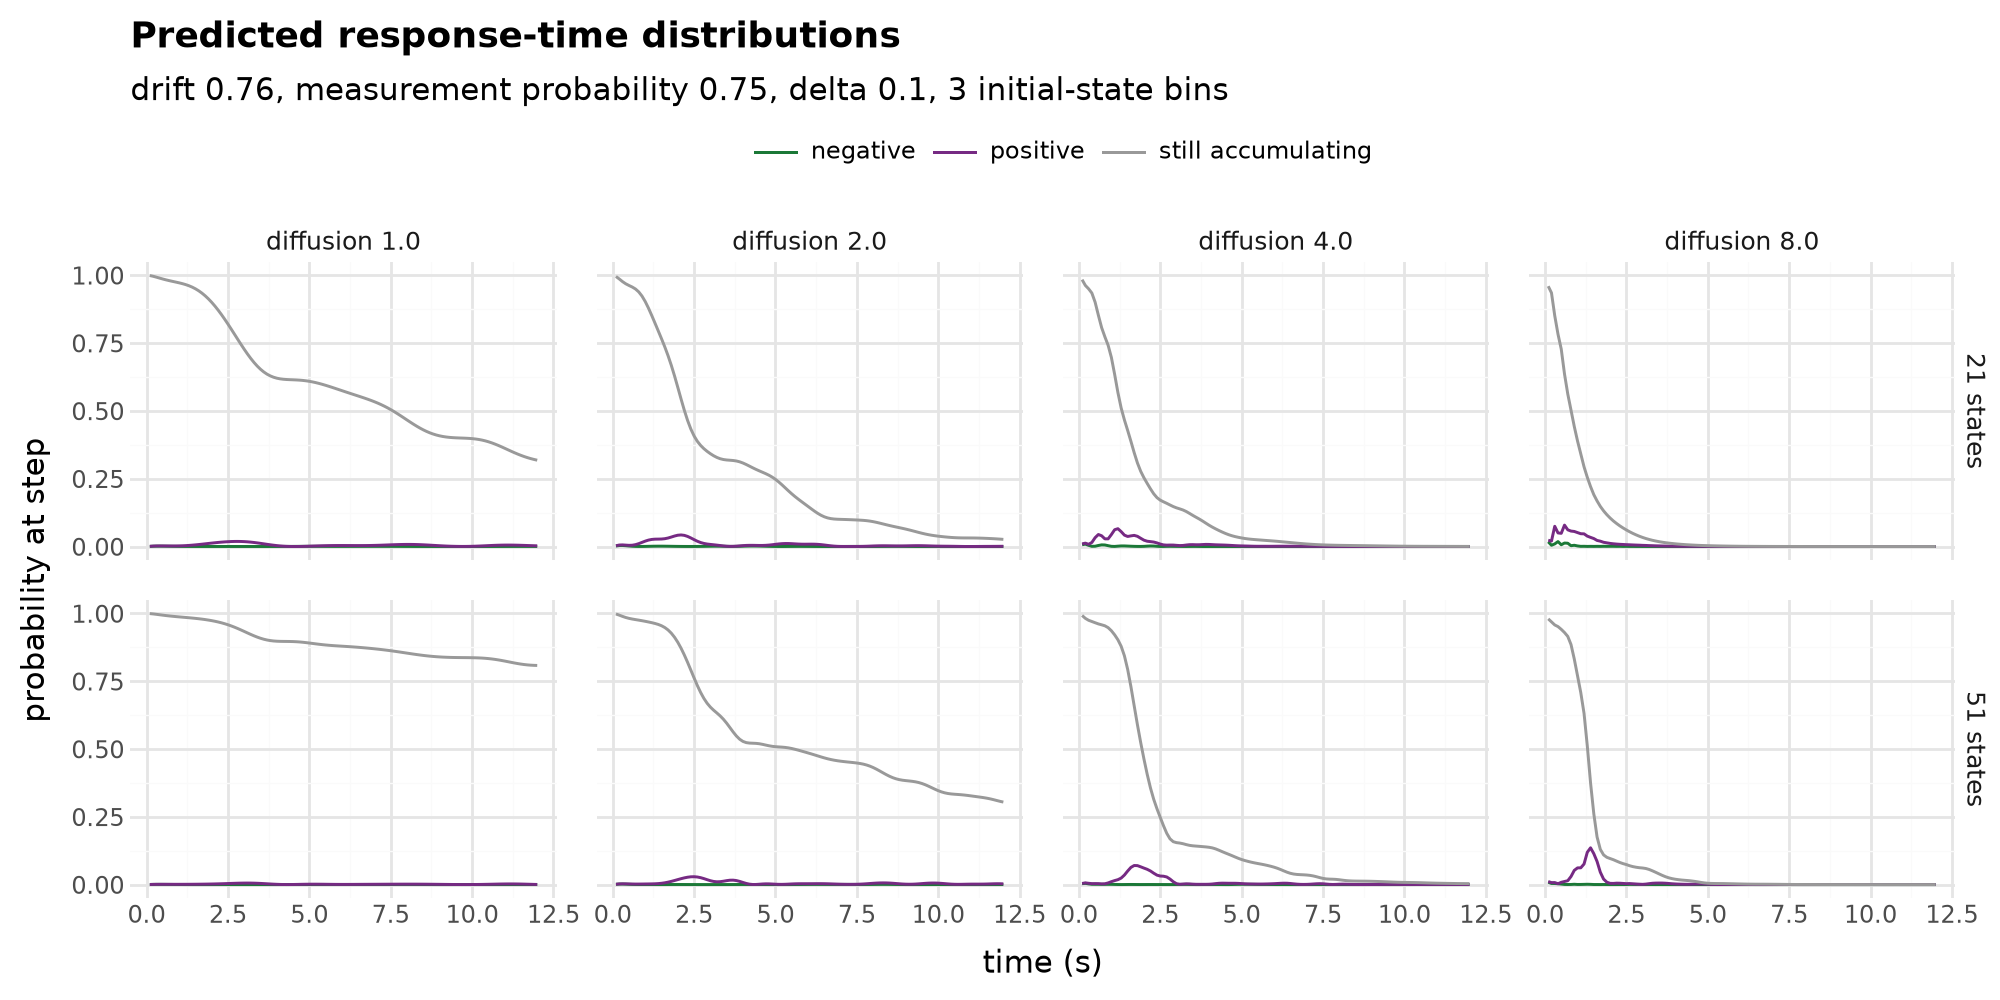

In [4]:
sig_majors = [1.0, 2.0, 4.0, 8.0]

rows = []
for name in grids:
    c = np.asarray(curves_for[name](npx.full(len(sig_majors), mu_ref), npx.asarray(sig_majors)))
    for s, cc in zip(sig_majors, c):
        for label, series in zip(["positive", "negative", "still accumulating"], cc):
            rows.append(pd.DataFrame({"t": times, "p": series, "response": label,
                                      "grid": name, "sigma": f"diffusion {s}"}))
pred = pd.concat(rows)
pred["sigma"] = pd.Categorical(pred.sigma, [f"diffusion {s}" for s in sig_majors])

(ggplot(pred, aes("t", "p", colour="response"))
 + geom_line(size=0.6)
 + facet_grid("grid ~ sigma", scales="free_y")
 + scale_colour_manual(["#1b7837", "#762a83", "#999999"])
 + labs(x="time (s)", y="probability at step", colour="",
        title="Predicted response-time distributions",
        subtitle=f"drift {mu_ref}, measurement probability 0.75, delta 0.1, 3 initial-state bins")
 + theme_minimal()
 + theme(figure_size=(10, 5), legend_position="top", panel_spacing=0.02,
         strip_text=element_text(size=9), plot_title=element_text(size=13, weight="bold")))

## Which diffusion rate puts the two grids on the same clock?

`sigma` is a rate in states per second, so the same value does not describe the same process on
a 7-state and a 17-state free region. Matching the **predicted median response time** across
grids is a statement about the model, not about any dataset, and it is the defensible way to
carry a value from one grid to the other.

21 states at sigma 3.16  -> median RT 1.60 s
51 states matches it at sigma 5.86   ratio 1.86x
free-state ratio 17/7 = 2.43x   square-root of it = 1.56x


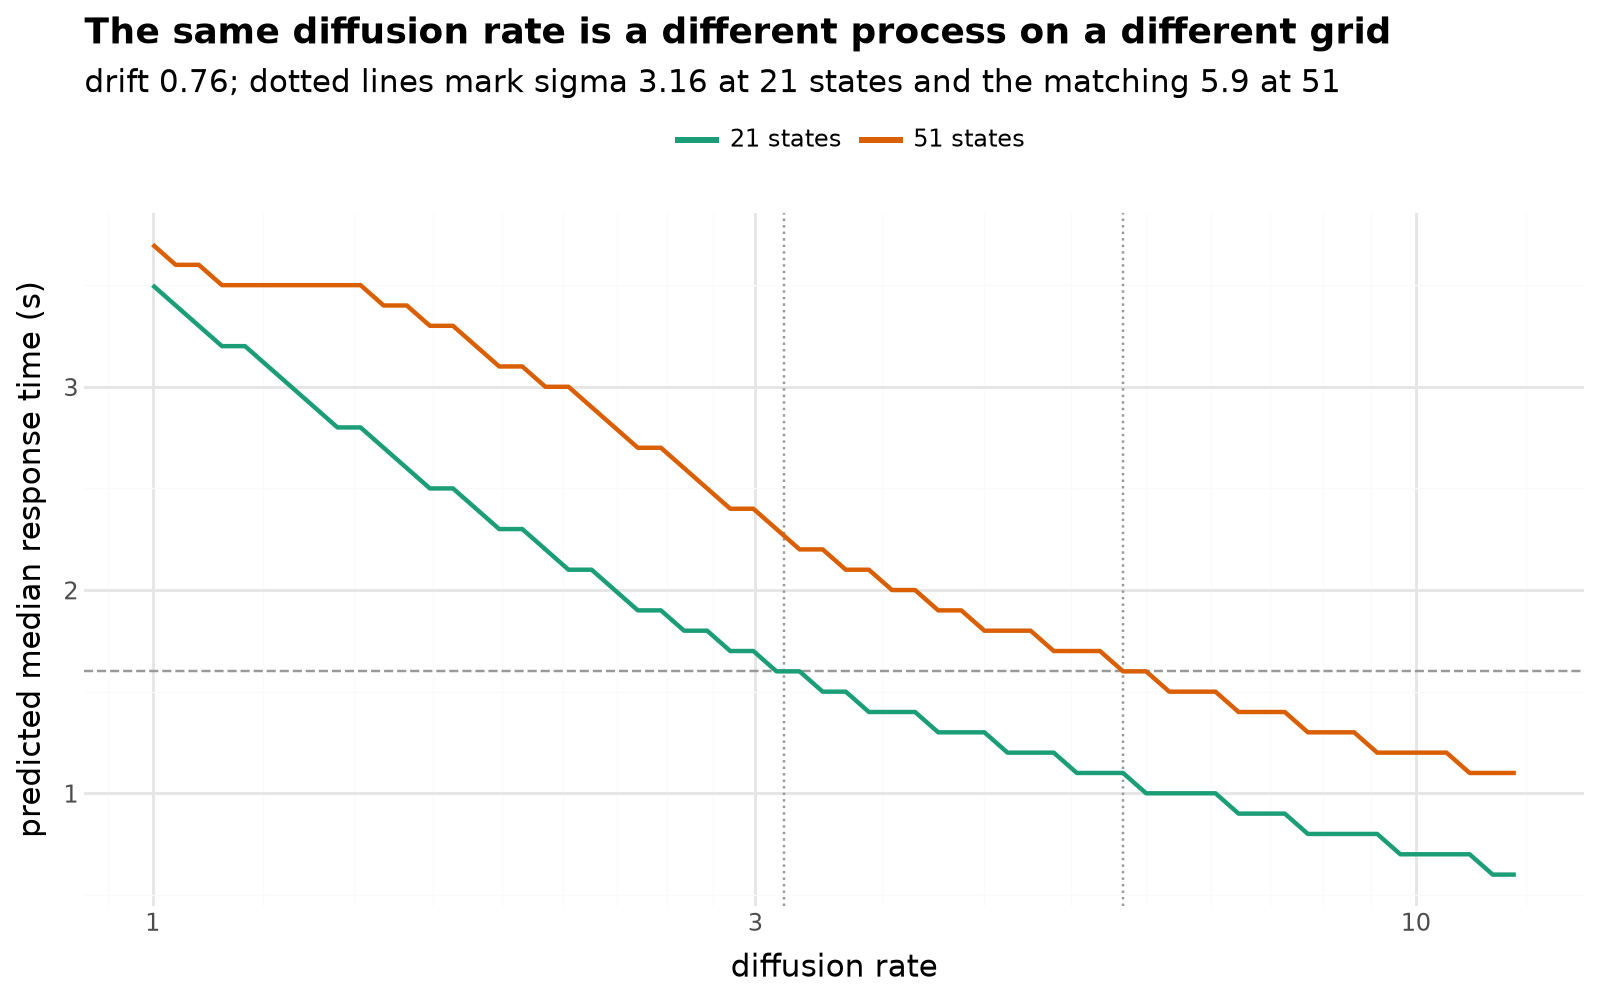

In [5]:
sig_fine = np.geomspace(1.0, 12.0, 60)

timing = pd.concat([
    pd.DataFrame({"sigma": sig_fine, "grid": name,
                  "median_rt": median_rt(curves_for[name](npx.full(sig_fine.shape, mu_ref),
                                                          npx.asarray(sig_fine)))})
    for name in grids])

small = timing[timing.grid == "21 states"]
target = float(small.median_rt.iloc[np.abs(small.sigma - 3.16).values.argmin()])
large = timing[timing.grid == "51 states"]
matched = float(large.sigma.iloc[np.abs(large.median_rt - target).values.argmin()])

print(f"21 states at sigma 3.16  -> median RT {target:.2f} s")
print(f"51 states matches it at sigma {matched:.2f}   ratio {matched / 3.16:.2f}x")
print(f"free-state ratio 17/7 = {17/7:.2f}x   square-root of it = {(17/7)**0.5:.2f}x")

(ggplot(timing, aes("sigma", "median_rt", colour="grid"))
 + geom_hline(yintercept=target, linetype="dashed", colour="#999999")
 + geom_vline(xintercept=[3.16, matched], linetype="dotted", colour="#999999")
 + geom_line(size=0.9)
 + scale_x_log10()
 + scale_colour_manual(["#1b9e77", "#d95f02"])
 + labs(x="diffusion rate", y="predicted median response time (s)", colour="",
        title="The same diffusion rate is a different process on a different grid",
        subtitle=f"drift {mu_ref}; dotted lines mark sigma 3.16 at 21 states and the matching {matched:.1f} at 51")
 + theme_minimal()
 + theme(figure_size=(8, 5), legend_position="top", plot_title=element_text(size=13, weight="bold")))

## How far apart must two diffusion rates be?

Every pair of `sigma` values on a fine grid, scored in nats over 30 trials. The dark band along
the diagonal is the region the design cannot resolve.

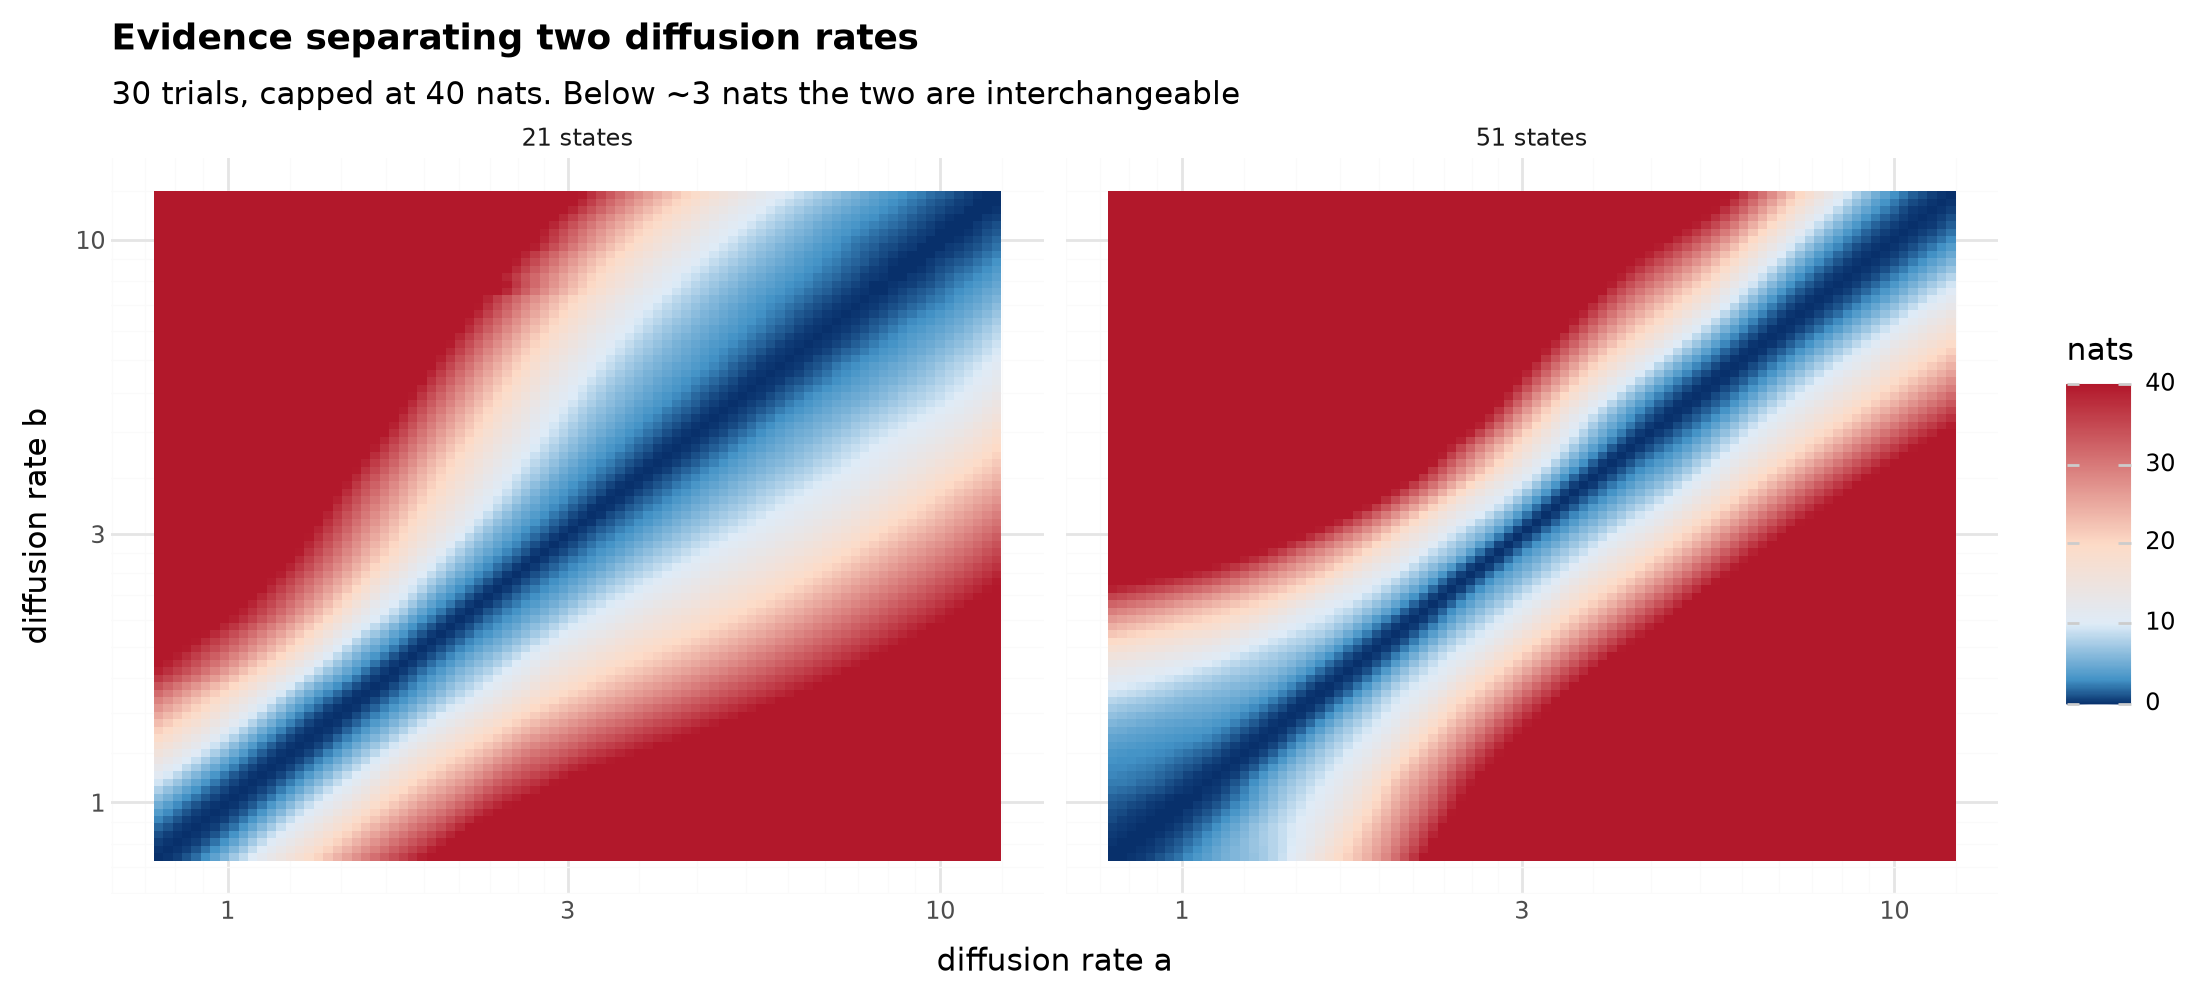

In [6]:
fine = np.geomspace(0.8, 12.0, 90)
D_for = {name: evidence(outcome_mass(curves_for[name](npx.full(fine.shape, mu_ref), npx.asarray(fine))))
         for name in grids}

heat = pd.concat([
    pd.DataFrame([(fine[i], fine[j], min(D_for[name][i, j], 40.0), name)
                  for i in range(len(fine)) for j in range(len(fine))],
                 columns=["sigma_a", "sigma_b", "nats", "grid"])
    for name in grids])

(ggplot(heat, aes("sigma_a", "sigma_b", fill="nats"))
 + geom_raster()
 + facet_wrap("~grid")
 + scale_x_log10() + scale_y_log10()
 + scale_fill_gradientn(["#08306b", "#4292c6", "#deebf7", "#fddbc7", "#b2182b"],
                        values=[0, 0.075, 0.25, 0.5, 1.0])
 + labs(x="diffusion rate a", y="diffusion rate b", fill="nats",
        title="Evidence separating two diffusion rates",
        subtitle="30 trials, capped at 40 nats. Below ~3 nats the two are interchangeable")
 + theme_minimal()
 + theme(figure_size=(11, 5), plot_title=element_text(size=13, weight="bold")))

## Minor perturbations

Holding everything else fixed, does moving `sigma` by 0.1, 0.2 or 0.3 change what the model
predicts? The dashed line is 3 nats, below which 30 trials cannot separate the two settings.

A fixed additive step falls off steeply because 0.3 is a 30% change at `sigma = 1` and a 5%
change at `sigma = 6` - most of that decline is the shrinking ratio, not the model losing
sensitivity. The next figure removes that effect.

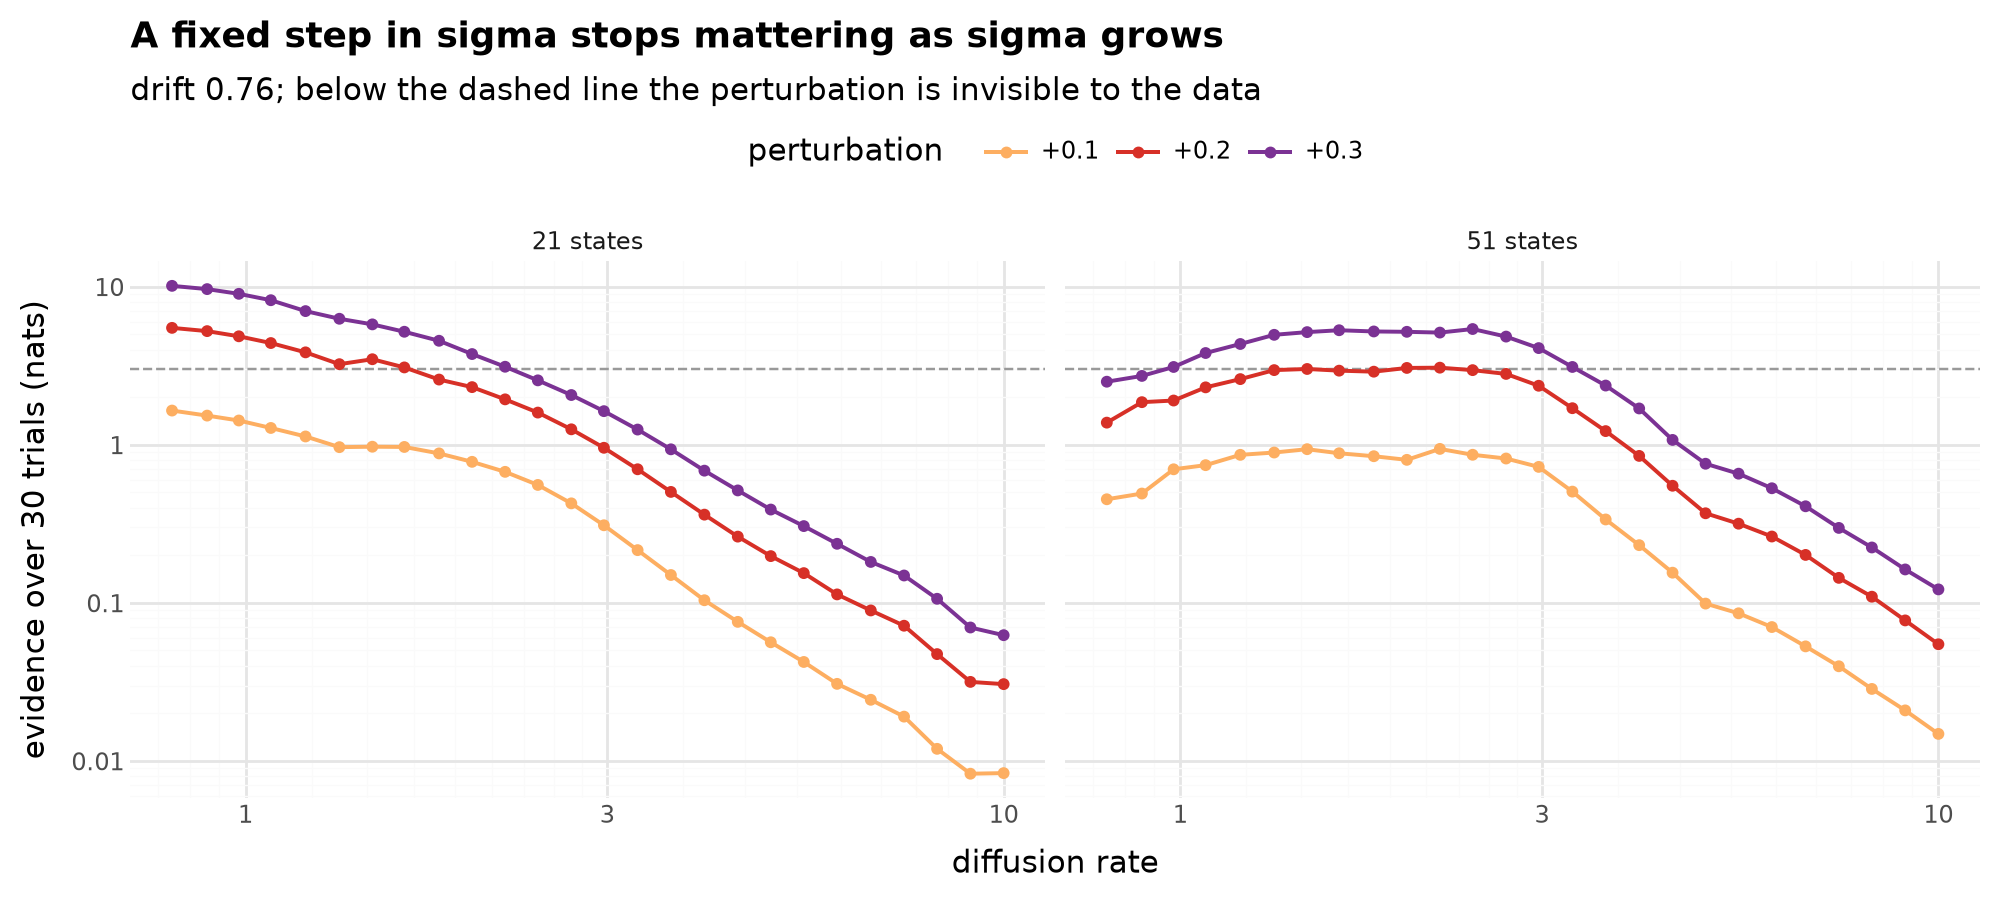

In [7]:
minors = [0.1, 0.2, 0.3]
bases = np.round(np.geomspace(0.8, 10.0, 26), 2)
pairs = [(b, b + d) for b in bases for d in minors]
flat = npx.asarray([v for pair in pairs for v in pair])

pert = pd.concat([
    pd.DataFrame({"sigma": [b for b, _ in pairs],
                  "step": [f"+{round(b2 - b, 1)}" for b, b2 in pairs],
                  "grid": name,
                  "nats": np.diag(evidence(outcome_mass(curves_for[name](npx.full(len(flat), mu_ref), flat))), 1)[::2]})
    for name in grids])

(ggplot(pert, aes("sigma", "nats", colour="step"))
 + geom_hline(yintercept=3.0, linetype="dashed", colour="#999999")
 + geom_line(size=0.8) + geom_point(size=1.4)
 + facet_wrap("~grid")
 + scale_x_log10() + scale_y_log10()
 + scale_colour_manual(["#fdae61", "#d73027", "#7b3294"])
 + labs(x="diffusion rate", y="evidence over 30 trials (nats)", colour="perturbation",
        title="A fixed step in sigma stops mattering as sigma grows",
        subtitle=f"drift {mu_ref}; below the dashed line the perturbation is invisible to the data")
 + theme_minimal()
 + theme(figure_size=(10, 4.5), legend_position="top", plot_title=element_text(size=13, weight="bold")))

## The identifiable window

For each `sigma`, the smallest multiplicative change a 30-trial design can detect at 3 nats.

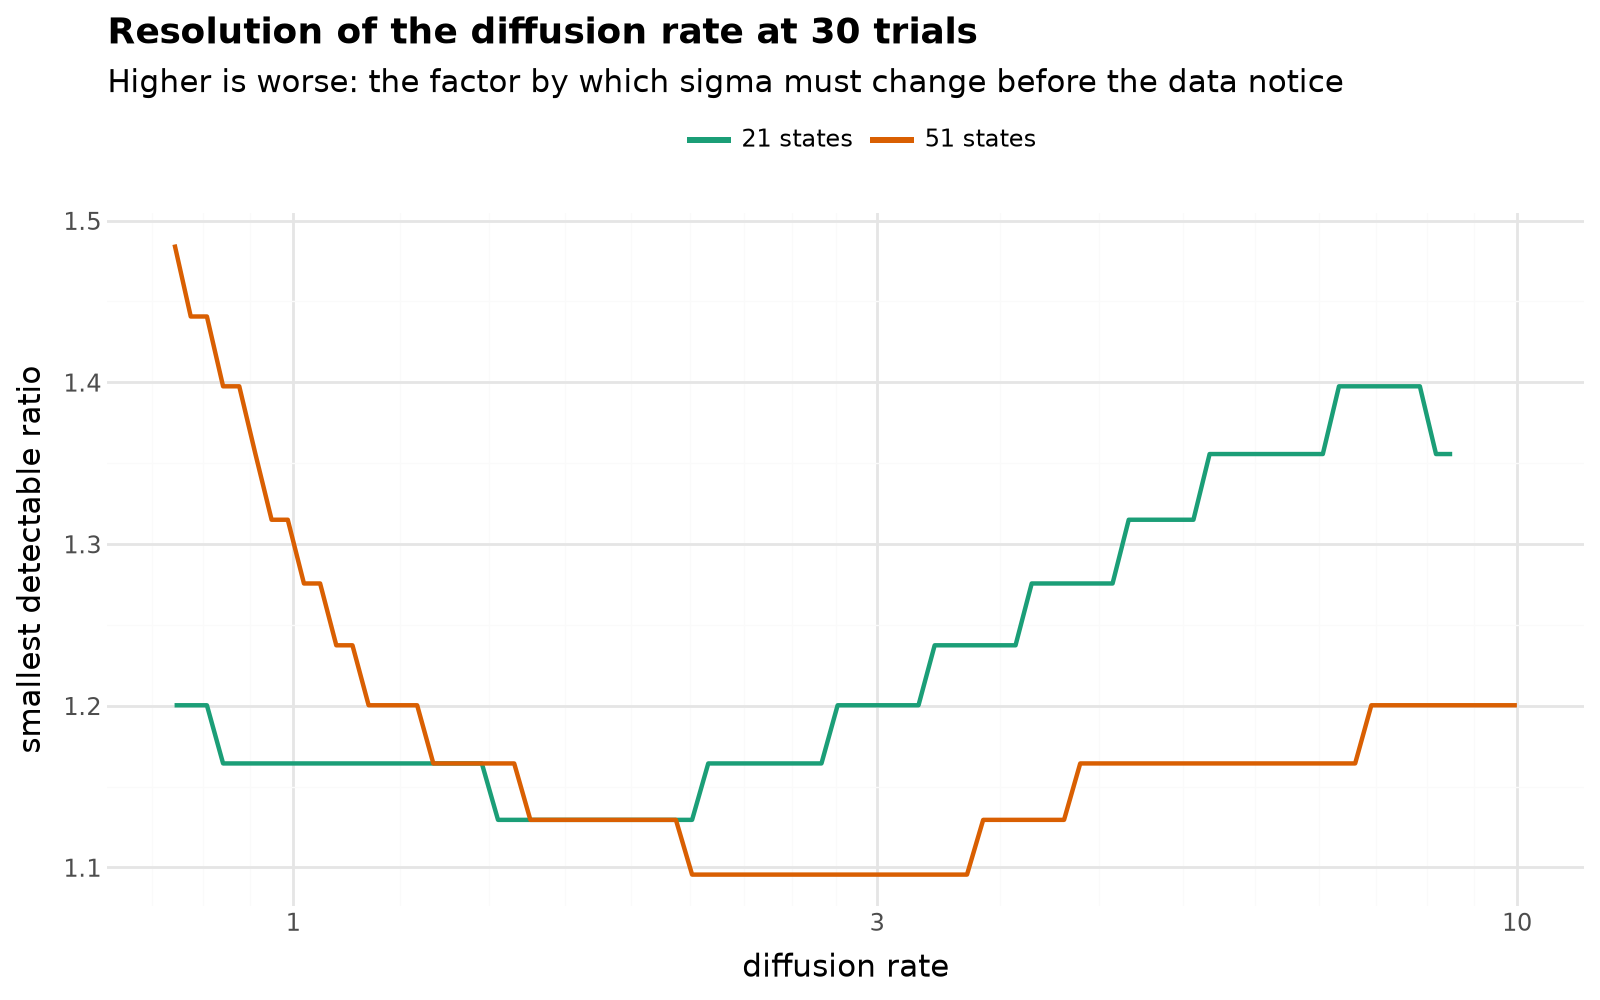

In [8]:
res = []
for name in grids:
    D = D_for[name]
    for i, s in enumerate(fine):
        hit = [fine[j] / s for j in range(i + 1, len(fine)) if D[i, j] >= 3.0]
        res.append({"sigma": s, "grid": name, "ratio": min(hit) if hit else np.nan})
res = pd.DataFrame(res).dropna()

(ggplot(res, aes("sigma", "ratio", colour="grid"))
 + geom_line(size=0.9)
 + scale_x_log10()
 + scale_colour_manual(["#1b9e77", "#d95f02"])
 + labs(x="diffusion rate", y="smallest detectable ratio", colour="",
        title="Resolution of the diffusion rate at 30 trials",
        subtitle="Higher is worse: the factor by which sigma must change before the data notice")
 + theme_minimal()
 + theme(figure_size=(8, 5), legend_position="top", plot_title=element_text(size=13, weight="bold")))

In [9]:
print(res.groupby("grid").apply(lambda g: pd.Series({
    "resolution at sigma 3": g.ratio[np.abs(g.sigma - 3.0).idxmin()],
    "resolution at sigma 6": g.ratio[np.abs(g.sigma - 6.0).idxmin()],
    "median resolution": g.ratio.median()}), include_groups=False).round(2).to_string())

           resolution at sigma 3  resolution at sigma 6  median resolution
grid                                                                      
21 states                    1.2                   1.36               1.20
51 states                    1.1                   1.16               1.16


## What this says about the prior

**The diffusion rate does not transfer between grids.** `sigma` is a rate in states per second,
so the same number describes a different process on a 7-state and a 17-state free region: at 51
states it produces a markedly later response-time distribution for the same drift. Matching the
predicted median response time is the model-internal way to carry a value across, and the
figure above gives the factor. Freezing both grids at the same number leaves the larger grid
natively too slow, and the drift and initial state then have to absorb the difference.

**Resolution is roughly a factor of 1.2 to 1.4 and close to flat across `sigma`,** on both
grids. It does not collapse at large `sigma`; the steep fall in the additive-step figure is a
ratio effect. Sensitivity is approximately scale-free, so the logarithmic parameterisation the
model already uses through `m_si` is the right one, and a prior narrower than about
`log(1.3) / 2 = 0.13` on `m_si` would pin `sigma` finer than 30 trials can resolve.

**What this rules out.** Rates separated by a factor of two are tens of nats apart. Two
diffusion rates that far apart are not interchangeable under this model, so multimodality at
that spacing cannot be blamed on the design.

One caveat to keep with the figures: this says which rates are *distinguishable*, not which are
*psychologically right*. That has to come from theory, and in Busemeyer's and Epping's
implementations the diffusion rate is fixed as the unit of the Hamiltonian - `H_off_diag` is a
vector of ones.